## Import Libraries

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import os
from pathlib import Path
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

print("Libraries installed successfully!")

Libraries installed successfully!


## 01_data_loading_and_merging.py

In [2]:
# Efficiently load, validate, clean, and merge multiple CSV files
# into a single dataset for time-series analysis.

In [3]:
# CONFIGURATION

DATA_DIR = Path("/content/pakistan_crop_prices_dataset")   # Location of CSV files in Colab
OUTPUT_FILE = Path("/content/merged_crop_prices.csv")

In [4]:
# FUNCTION: Load & Validate Single File

def load_and_validate(file_path):
    """
    Loads a CSV file and validates its schema.
    """

    try:
        df = pd.read_csv(file_path)

        # Expected schema
        required_columns = {"City", "Date", "Crop", "Price"}

        if not required_columns.issubset(df.columns):
            print(f"[WARNING] Skipping {file_path.name} (invalid schema)")
            return None

        return df

    except Exception as e:
        print(f"[ERROR] Failed to read {file_path.name}: {e}")
        return None

In [5]:
def clean_dataframe(df):
    """
    Cleans a single dataframe before merging.
    """

    # Convert Date → datetime
    # Explicitly setting a format to avoid UserWarning about inferring format
    # Common formats include '%Y-%m-%d', '%m/%d/%Y', etc. Choosing '%Y-%m-%d' as a common default.
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors="coerce")

    # Convert Price → numeric
    df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

    # Remove invalid rows
    df = df.dropna(subset=["Date", "Price"])

    return df

In [6]:
# FUNCTION: Load All Files Efficiently

def load_all_files(data_dir):
    """
    Loads all CSV files one-by-one (memory efficient).
    """

    csv_files = list(data_dir.glob("*.csv"))

    print(f"\n[INFO] Found {len(csv_files)} CSV files.\n")

    all_dataframes = []

    for idx, file in enumerate(csv_files, 1):
        print(f"[{idx}/{len(csv_files)}] Processing: {file.name}")

        df = load_and_validate(file)

        if df is not None:
            df = clean_dataframe(df)
            all_dataframes.append(df)

    print(f"\n[INFO] Successfully loaded {len(all_dataframes)} datasets.")

    return all_dataframes

In [7]:
# FUNCTION: Merge Datasets

def merge_datasets(dataframes):
    """
    Merge all dataframes into one large dataset.
    """

    print("\n[INFO] Merging datasets...")

    merged_df = pd.concat(dataframes, ignore_index=True)

    print(f"[INFO] Total rows after merge: {len(merged_df)}")

    return merged_df

In [8]:
# FUNCTION: Final Processing

def finalize_dataset(df):
    """
    Final preparation for time-series analysis.
    """

    print("\n[INFO] Finalizing dataset...")

    # Sort for time-series correctness
    df = df.sort_values(by=["Crop", "City", "Date"])

    # Reset index
    df.reset_index(drop=True, inplace=True)

    return df

In [9]:
# MAIN PIPELINE

def main():

    print("======================================")
    print(" DATA LOADING & MERGING (COLAB MODE) ")
    print("========================================\n")

    # Step 1: Load all datasets
    datasets = load_all_files(DATA_DIR)

    if len(datasets) == 0:
        print("[ERROR] No valid datasets found. Exiting.")
        return

    # Step 2: Merge
    merged_df = merge_datasets(datasets)

    # Step 3: Final processing
    merged_df = finalize_dataset(merged_df)

    # Step 4: Save dataset
    merged_df.to_csv(OUTPUT_FILE, index=False)

    print(f"\n[INFO] Dataset saved at: {OUTPUT_FILE}")

    # Step 5: Summary (Important for report)
    print("\n========== DATA SUMMARY ==========")
    print(f"Total Records : {len(merged_df)}")
    print(f"Total Cities  : {merged_df['City'].nunique()}")
    print(f"Total Crops   : {merged_df['Crop'].nunique()}")
    print(f"Date Range    : {merged_df['Date'].min()} -> {merged_df['Date'].max()}")
    print("==================================")

if __name__ == "__main__":
    main()

 DATA LOADING & MERGING (COLAB MODE) 


[INFO] Found 53 CSV files.

[1/53] Processing: Capsicum.csv
[2/53] Processing: jaman.csv
[3/53] Processing: Banana(Dozens).csv
[4/53] Processing: Batho.csv
[5/53] Processing: Banana.csv
[6/53] Processing: gram white (local).csv
[7/53] Processing: lemon.csv
[8/53] Processing: kinnow.csv
[9/53] Processing: gram pulse.csv
[10/53] Processing: green onion.csv
[11/53] Processing: green fodder.csv
[12/53] Processing: grapes.csv
[13/53] Processing: coriander.csv
[14/53] Processing: Apple_Golden.csv
[15/53] Processing: grapefruit.csv
[16/53] Processing: groundnut.csv
[17/53] Processing: AppleKala Kullu (Madani).csv
[18/53] Processing: coconut.csv
[19/53] Processing: mango.csv
[20/53] Processing: Pomegranate.csv
[21/53] Processing: orange.csv
[22/53] Processing: masoor.csv
[23/53] Processing: Apricot Yellow.csv
[24/53] Processing: cucumber.csv
[25/53] Processing: moong_moongray.csv
[26/53] Processing: gram white (imported).csv
[27/53] Processing: Canola.cs

# 02_preprocessing_exploratory_data_analysis.py

In [10]:
# Perform exploratory data analysis (EDA) on merged crop price dataset.
# Includes statistical summaries, time-based feature extraction, and visualization for trend discovery.
# Comprehensive preprocessing pipeline for time-series crop price data.
# - Missing value handling
# - Time-series regularization
# - Feature engineering
# - Normalization
# - Data filtering

In [11]:
# DIRECTORY SETUP

def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)


BASE_DIR = "outputs"
create_dir(BASE_DIR)

In [12]:
DATA_FILE = "/content/merged_crop_prices.csv"
print("Data path checked and load into a particular varialble successfully!")

Data path checked and load into a particular varialble successfully!


In [13]:
df = pd.read_csv(DATA_FILE)
df.head()

,City,Date,Crop,Price,Unnamed: 1,Unnamed: 3,Unnamed: 5,Unnamed: 6
0,Abdulhakim,2008-04-16,Apple (Ammre),6300,NaN,NaN,NaN,NaN
1,Abdulhakim,2008-04-17,Apple (Ammre),5550,NaN,NaN,NaN,NaN
2,Abdulhakim,2019-12-17,Apple (Ammre),11250,NaN,NaN,NaN,NaN
3,Abdulhakim,2019-12-21,Apple (Ammre),8550,NaN,NaN,NaN,NaN
4,Abdulhakim,2019-12-22,Apple (Ammre),8550,NaN,NaN,NaN,NaN


In [14]:
unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
print(f"Columns to be removed: {unnamed_cols}")

df = df.drop(columns=unnamed_cols)

print("DataFrame after removing 'Unnamed' columns:")
df.head()

Columns to be removed: ['Unnamed: 1', 'Unnamed: 3', 'Unnamed: 5', 'Unnamed: 6']
DataFrame after removing 'Unnamed' columns:


,City,Date,Crop,Price
0,Abdulhakim,2008-04-16,Apple (Ammre),6300
1,Abdulhakim,2008-04-17,Apple (Ammre),5550
2,Abdulhakim,2019-12-17,Apple (Ammre),11250
3,Abdulhakim,2019-12-21,Apple (Ammre),8550
4,Abdulhakim,2019-12-22,Apple (Ammre),8550


## Basic data overview and it's Inspection

In [15]:
def dataset_shape(df):
    print("Dataset Shape:", df.shape)

In [16]:
dataset_shape(df)

Dataset Shape: (7989418, 4)


In [17]:
def dataset_columns(df):
    print("Columns:\n", df.columns)

In [18]:
dataset_columns(df)

Columns:
 Index(['City', 'Date', 'Crop', 'Price'], dtype='object')


In [19]:
def dataset_datatypes(df):
    print("Data Types:\n", df.dtypes)

In [20]:
dataset_datatypes(df)

Data Types:
 City     object
Date     object
Crop     object
Price     int64
dtype: object


In [21]:
def dataset_head(df):
    print("First 5 Rows:\n", df.head())

In [22]:
dataset_head(df)

First 5 Rows:
          City        Date           Crop  Price
0  Abdulhakim  2008-04-16  Apple (Ammre)   6300
1  Abdulhakim  2008-04-17  Apple (Ammre)   5550
2  Abdulhakim  2019-12-17  Apple (Ammre)  11250
3  Abdulhakim  2019-12-21  Apple (Ammre)   8550
4  Abdulhakim  2019-12-22  Apple (Ammre)   8550


In [23]:
def dataset_description(df):
    print("Statistical Summary:\n", df.describe())

In [24]:
dataset_description(df)

Statistical Summary:
               Price
count  7.989418e+06
mean   5.475359e+03
std    6.483688e+03
min    0.000000e+00
25%    0.000000e+00
50%    3.600000e+03
75%    9.000000e+03
max    9.785000e+04


In [25]:
def missing_values(df):
    print("Missing Values:\n", df.isnull().sum())

In [26]:
missing_values(df)

Missing Values:
 City     0
Date     0
Crop     0
Price    0
dtype: int64


In [27]:
def unique_cities(df):
    print("\nUnique Cities:", df["City"].nunique())

In [28]:
unique_cities(df)


Unique Cities: 138


In [29]:
def unique_crops(df):
    print("Unique Crops:", df["Crop"].nunique())

In [30]:
unique_crops(df)

Unique Crops: 76


## Cleaning the entire dataset

In [31]:
def remove_duplicates(df):
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]

    print("Duplicates removed:", before - after)
    print("\n[INFO] Removing duplicate records...")
    df = df.drop_duplicates(subset=["City", "Crop", "Date"])
    return df

In [32]:
# OUTLIER HANDLING (MODIFIED)

def remove_outliers(df):
    print("[INFO] Removing outliers using IQR...")

    def filter_group(group):
        Q1 = group["Price"].quantile(0.25)
        Q3 = group["Price"].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        return group[(group["Price"] >= lower) & (group["Price"] <= upper)]

    df = df.groupby(["City", "Crop"]).apply(filter_group).reset_index(drop=True)

    return df

In [33]:
df = remove_outliers(df)

[INFO] Removing outliers using IQR...


/tmp/ipykernel_27654/2361860427.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["City", "Crop"]).apply(filter_group).reset_index(drop=True)


In [34]:
def fill_missing_dates(df):
    """
    For each (City, Crop), ensure continuous date sequence.
    """

    print("[INFO] Filling missing dates (time-series regularization)...")

    # Ensure Date column is datetime type before processing
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # Drop rows where Date could not be parsed, to prevent issues with min/max or grouping
    df = df.dropna(subset=["Date"])

    processed_groups = []

    grouped = df.groupby(["City", "Crop"])

    for (city, crop), group in grouped:

        group = group.sort_values("Date")

        group = group.groupby("Date")["Price"].mean().reset_index() # Handle duplicate dates by taking the mean of 'Price'
        group["City"] = city
        group["Crop"] = crop

        full_range = pd.date_range(start=group["Date"].min(),
                                   end=group["Date"].max(),
                                   freq='D')

        group = group.set_index("Date").reindex(full_range) # Reindex to ensure continuous dates, filling missing dates with NaN for Price

        # Re-assign City and Crop as they might become NaN during reindex for new dates
        group["City"] = city
        group["Crop"] = crop

        group["Price"] = group["Price"].interpolate(method='linear', limit_direction='both') # Interpolate missing prices, including those at the start/end
        group["Price"] = group["Price"].fillna(method='ffill').fillna(method='bfill') # Fill any remaining NaNs using forward-fill then backward-fill

        group = group.reset_index().rename(columns={"index": "Date"})

        processed_groups.append(group)

    df = pd.concat(processed_groups, ignore_index=True)

    return df

## Featuring and normalization

In [35]:
# FEATURE ENGINEERING (TIME FEATURES)

def create_time_features(df):
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek

    return df

In [36]:
create_time_features(df)

,City,Date,Crop,Price,Year,Month,Day,DayOfWeek
0,Abdulhakim,2019-12-21,Apple (Ammre),8550,2019,12,21,5
1,Abdulhakim,2019-12-22,Apple (Ammre),8550,2019,12,22,6
2,Abdulhakim,2019-12-25,Apple (Ammre),8550,2019,12,25,2
3,Abdulhakim,2019-12-26,Apple (Ammre),8550,2019,12,26,3
4,Abdulhakim,2019-12-28,Apple (Ammre),8550,2019,12,28,5
...,...,...,...,...,...,...,...,...
7651138,kotmoman,2021-03-13,green chickpeas(چھولیا),3500,2021,3,13,5
7651139,kotmoman,2021-03-17,green chickpeas(چھولیا),4050,2021,3,17,2
7651140,kotmoman,2021-03-27,green chickpeas(چھولیا),2750,2021,3,27,5
7651141,kotmoman,2021-03-29,green chickpeas(چھولیا),3250,2021,3,29,0


In [37]:
# NORMALIZATION (ADAPTED)

def normalize_prices(df):
    print("[INFO] Normalizing prices (Min-Max scaling per crop)...")
    df["Normalized_Price"] = df.groupby("Crop")["Price"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min())
    )
    return df


In [38]:
df = normalize_prices(df)

[INFO] Normalizing prices (Min-Max scaling per crop)...


In [39]:
# FILTER LOW-DATA SERIES

def filter_short_series(df, min_length=100):
    print("[INFO] Filtering short time-series...")

    valid_series = df.groupby(["City", "Crop"]).filter(lambda x: len(x) >= min_length)

    return valid_series

In [40]:
def encode_categorical(df):
    print("[INFO] Encoding categorical variables...")

    le = LabelEncoder()

    df["City_encoded"] = le.fit_transform(df["City"])
    df["Crop_encoded"] = le.fit_transform(df["Crop"])

    return df

In [41]:
df = encode_categorical(df)

[INFO] Encoding categorical variables...


In [42]:
df.head()

,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded
0,Abdulhakim,2019-12-21,Apple (Ammre),8550,2019,12,21,5,0.400406,0,0
1,Abdulhakim,2019-12-22,Apple (Ammre),8550,2019,12,22,6,0.400406,0,0
2,Abdulhakim,2019-12-25,Apple (Ammre),8550,2019,12,25,2,0.400406,0,0
3,Abdulhakim,2019-12-26,Apple (Ammre),8550,2019,12,26,3,0.400406,0,0
4,Abdulhakim,2019-12-28,Apple (Ammre),8550,2019,12,28,5,0.400406,0,0


## Preprocessing Pipeline

In [43]:
# MAIN PIPELINE

def run_pipeline(df):
    print("======================================")
    print(" PREPROCESSING PIPELINE ")
    print("======================================\n")

    print("\n========== DATASET INSPECTION ==========")

    dataset_shape(df)
    dataset_columns(df)
    dataset_datatypes(df)
    dataset_head(df)
    dataset_description(df)
    missing_values(df)

    print("\n========== PREPROCESSING ==========")

    df = remove_duplicates(df)
    df = fill_missing_dates(df)
    filter_short_series(df)

    print("\nPREPROCESSING COMPLETED!")

    print("\nFinal Dataset Info:")
    print(df.info())

    return df

In [44]:
run_pipeline(df)

 PREPROCESSING PIPELINE 


========== DATASET INSPECTION ==========
Dataset Shape: (7651143, 11)
Columns:
 Index(['City', 'Date', 'Crop', 'Price', 'Year', 'Month', 'Day', 'DayOfWeek',
       'Normalized_Price', 'City_encoded', 'Crop_encoded'],
      dtype='object')
Data Types:
 City                        object
Date                datetime64[ns]
Crop                        object
Price                        int64
Year                         int32
Month                        int32
Day                          int32
DayOfWeek                    int32
Normalized_Price           float64
City_encoded                 int64
Crop_encoded                 int64
dtype: object
First 5 Rows:
          City       Date           Crop  Price  Year  Month  Day  DayOfWeek  \
0  Abdulhakim 2019-12-21  Apple (Ammre)   8550  2019     12   21          5   
1  Abdulhakim 2019-12-22  Apple (Ammre)   8550  2019     12   22          6   
2  Abdulhakim 2019-12-25  Apple (Ammre)   8550  2019     12   25      

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_27654/1461217614.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group["Price"] = group["Price"].fillna(method='ffill').fillna(method='bfill') # Fill any remaining NaNs using forward-fill then backward-fill
/tmp/ipykernel_27654/1461217614.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group["Price"] = group["Price"].fillna(method='ffill').fillna(method='bfill') # Fill any remaining NaNs using forward-fill then backward-fill
/tmp/ipykernel_27654/1461217614.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group["Price"] = group["Price"].fillna(method='ffill').fillna(method='bfill') # Fill any remaining NaNs using forward-fill then backward-fill
/

[INFO] Filtering short time-series...

PREPROCESSING COMPLETED!

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28705151 entries, 0 to 28705150
Data columns (total 4 columns):
 #   Column  Dtype         
---  ------  -----         
 0   Date    datetime64[ns]
 1   Price   float64       
 2   City    object        
 3   Crop    object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 876.0+ MB
None


,Date,Price,City,Crop
0,2019-12-21,8550.0,Abdulhakim,Apple (Ammre)
1,2019-12-22,8550.0,Abdulhakim,Apple (Ammre)
2,2019-12-23,8550.0,Abdulhakim,Apple (Ammre)
3,2019-12-24,8550.0,Abdulhakim,Apple (Ammre)
4,2019-12-25,8550.0,Abdulhakim,Apple (Ammre)
...,...,...,...,...
28705146,2021-03-27,2750.0,kotmoman,green chickpeas(چھولیا)
28705147,2021-03-28,3000.0,kotmoman,green chickpeas(چھولیا)
28705148,2021-03-29,3250.0,kotmoman,green chickpeas(چھولیا)
28705149,2021-03-30,3525.0,kotmoman,green chickpeas(چھولیا)


In [45]:
CLEANED_OUTPUT_FILE = Path("/content/cleaned_merged_crop_prices.csv")

df.to_csv(CLEANED_OUTPUT_FILE, index=False)
print(f"[INFO] Cleaned dataset saved at: {CLEANED_OUTPUT_FILE}")

[INFO] Cleaned dataset saved at: /content/cleaned_merged_crop_prices.csv


In [46]:
CLEANED_OUTPUT_FILE = "/content/cleaned_merged_crop_prices.csv"
files.download(CLEANED_OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
OUTPUT_FILE = "/content/merged_crop_prices.csv"
files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
df = pd.read_csv("/content/cleaned_merged_crop_prices.csv")
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded
0,Abdulhakim,2019-12-21,Apple (Ammre),8550,2019,12,21,5,0.400406,0,0
1,Abdulhakim,2019-12-22,Apple (Ammre),8550,2019,12,22,6,0.400406,0,0
2,Abdulhakim,2019-12-25,Apple (Ammre),8550,2019,12,25,2,0.400406,0,0
3,Abdulhakim,2019-12-26,Apple (Ammre),8550,2019,12,26,3,0.400406,0,0
4,Abdulhakim,2019-12-28,Apple (Ammre),8550,2019,12,28,5,0.400406,0,0


In [49]:
# 1. MISSING DATE HANDLING
# Time-series data must be continuous for meaningful analysis.
# We generate a full daily date range for each (City, Crop) pair and fill missing values using linear interpolation.

# 2. OUTLIER REMOVAL
# Extreme price spikes can distort trend analysis.
# We use IQR-based filtering per group to remove anomalies.

# 3. FEATURE ENGINEERING
# Time-based features (Month, DayOfWeek) help capture seasonality.

# 4. NORMALIZATION
# Prices differ greatly across crops (e.g., Apple vs Onion).
# We normalize per crop to make patterns comparable.

# 5. FILTERING SHORT SERIES
# Very short time-series are unreliable for analysis,
# so we remove groups with insufficient data.

# 6. This preprocessing ensures:
# - clean time-series structure
# - comparable data across crops
# - reliable trend and clustering results

## EDA and Visualization

In [50]:
# SAVE + SHOW FUNCTION

def save_and_show(name, folder):
    create_dir(folder)
    path = os.path.join(folder, f"{name}.png")
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {path}")


In [51]:
# FINAL EDA (ADAPTED FROM YOUR STRUCTURE)
# 1. Price Distribution
def plot_price_distribution(df):
    plt.figure()
    plt.hist(df["Price"], bins=50)
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    save_and_show("price_distribution", "outputs/distribution")

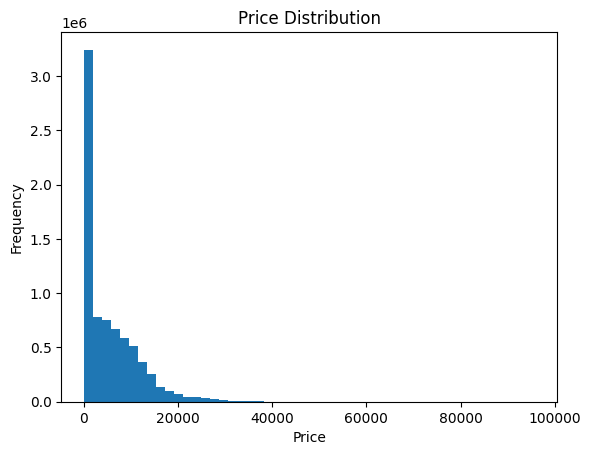

[SAVED] outputs/distribution/price_distribution.png


In [52]:
plot_price_distribution(df)

In [53]:
# 2. Time-Series Trend
def plot_time_series(df):
    ts = df.groupby("Date")["Price"].mean()

    plt.figure()
    plt.plot(ts.index, ts.values)
    plt.title("Overall Price Trend Over Time")
    save_and_show("time_series_trend", "outputs/trends")


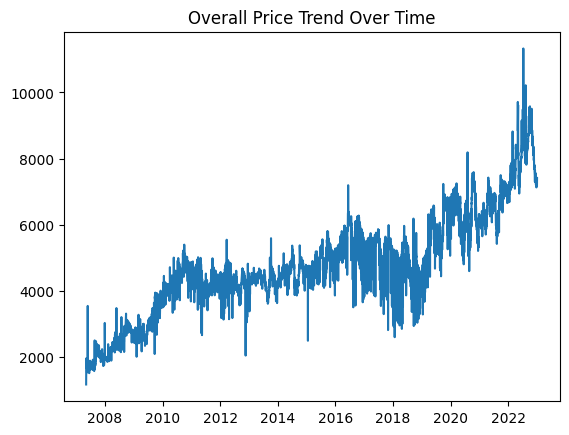

[SAVED] outputs/trends/time_series_trend.png


In [54]:
plot_time_series(df)

In [55]:
# 3. YEARLY TREND

def yearly_trend(df):
    print("\n[INFO] Analyzing yearly trends...")

    yearly_avg = df.groupby("Year")["Price"].mean()

    plt.figure()
    plt.plot(yearly_avg.index, yearly_avg.values)
    plt.title("Yearly Average Price Trend")
    plt.xlabel("Year")
    plt.ylabel("Average Price")
    save_and_show("yearly_trend", "outputs/trends")


[INFO] Analyzing yearly trends...


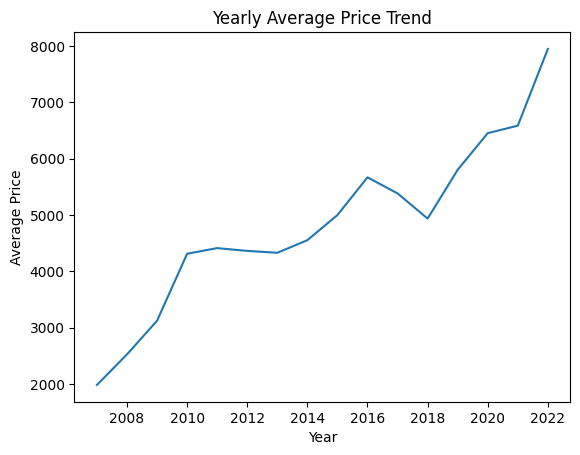

[SAVED] outputs/trends/yearly_trend.png


In [56]:
yearly_trend(df)

In [57]:
# 4. TOP CROPS ANALYSIS

def top_crops_analysis(df):
    print("\n[INFO] Analyzing top crops...")

    top_crops = df["Crop"].value_counts().head(5).index

    plt.figure()

    for crop in top_crops:
        subset = df[df["Crop"] == crop]
        grouped = subset.groupby("Date")["Price"].mean()

        plt.plot(grouped.index, grouped.values, label=crop)

    plt.title("Top 5 Crops Price Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average Price")
    plt.legend()
    save_and_show("top_crops_analysis", "outputs/analysis")


[INFO] Analyzing top crops...


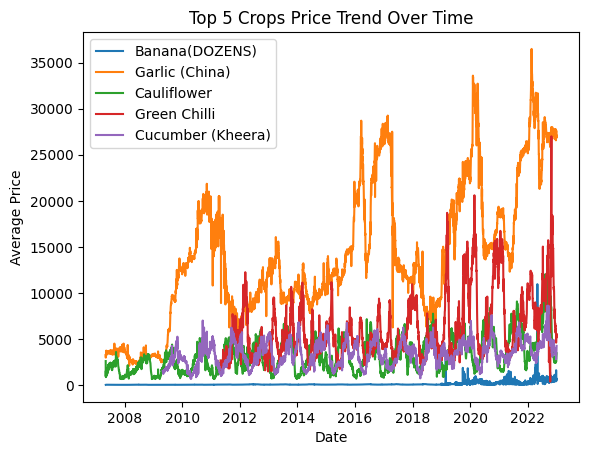

[SAVED] outputs/analysis/top_crops_analysis.png


In [58]:
top_crops_analysis(df)

In [59]:
# 5. Crop Distribution
def crop_distribution(df):
    counts = df["Crop"].value_counts().head(10)

    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.xticks(rotation=45)
    plt.title("Top Crops Distribution")

    save_and_show("crop_distribution", "outputs/crops")

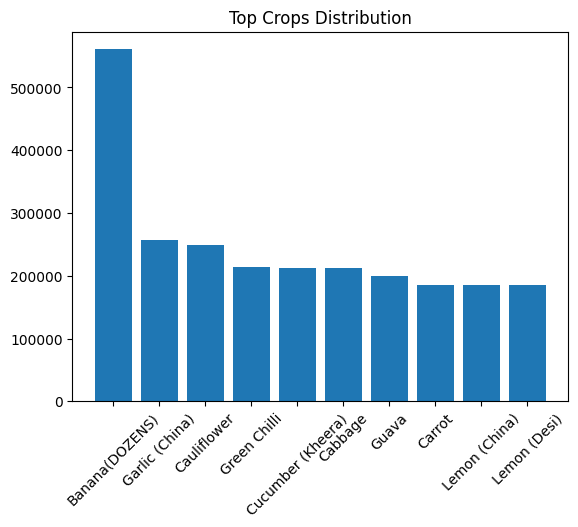

[SAVED] outputs/crops/crop_distribution.png


In [60]:
crop_distribution(df)

In [61]:
# 6. Monthly Seasonality or # Seasonal Analysis
def monthly_seasonality(df):
    print("\n[INFO] Analyzing monthly seasonality...")
    monthly_avg = df.groupby("Month")["Price"].mean()

    plt.figure()
    plt.plot(monthly_avg.index, monthly_avg.values)
    plt.title("Average Monthly Price (Seasonality)")
    plt.xlabel("Month")
    plt.ylabel("Average Price")

    save_and_show("monthly_seasonality", "outputs/seasonality")


[INFO] Analyzing monthly seasonality...


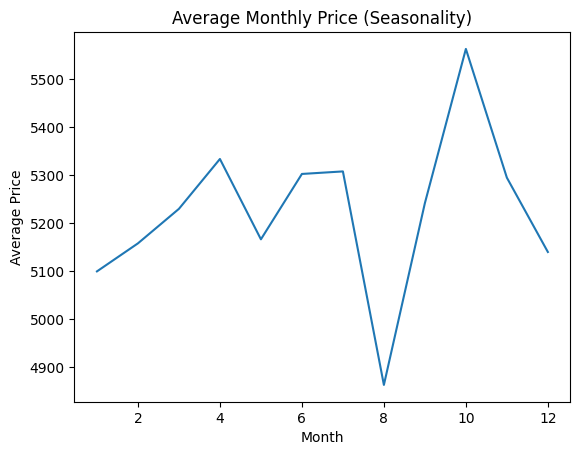

[SAVED] outputs/seasonality/monthly_seasonality.png


In [62]:
monthly_seasonality(df)

In [63]:
# 7. City-wise Comparison
def city_comparison(df):
    print("\n[INFO] Comparing cities...")
    city_avg = df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

    plt.figure()
    plt.bar(city_avg.index, city_avg.values)
    plt.xticks(rotation=45)
    plt.title("Top Cities by Avg Price")

    save_and_show("city_comparison", "outputs/city")


[INFO] Comparing cities...


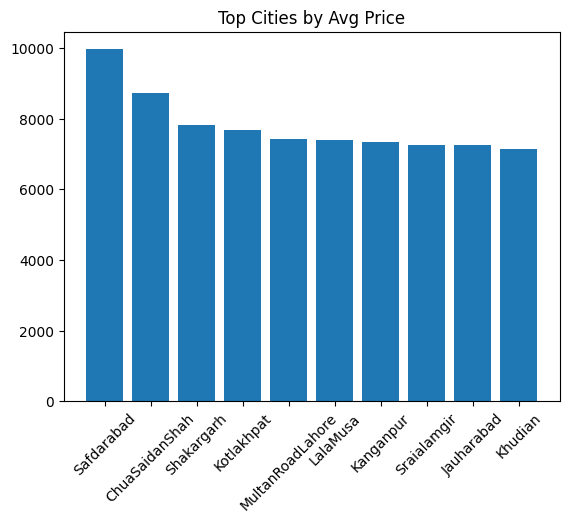

[SAVED] outputs/city/city_comparison.png


In [64]:
city_comparison(df)

In [65]:
# 8. Volatility (Important Insight)
def volatility_plot(df):
    print("\n[INFO] Calculating crop volatility...")

    vol = df.groupby("Crop")["Price"].std().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6)) # Increase figure size
    plt.bar(vol.index, vol.values)
    plt.title("Top 10 Most Volatile Crops")
    plt.xlabel("Crop")
    plt.ylabel("Standard Deviation (Volatility)")
    plt.xticks(rotation=45) # Rotate labels to 90 degrees
    plt.tight_layout() # Adjust layout to prevent labels from overlapping

    save_and_show("volatility", "outputs/volatility")


[INFO] Calculating crop volatility...


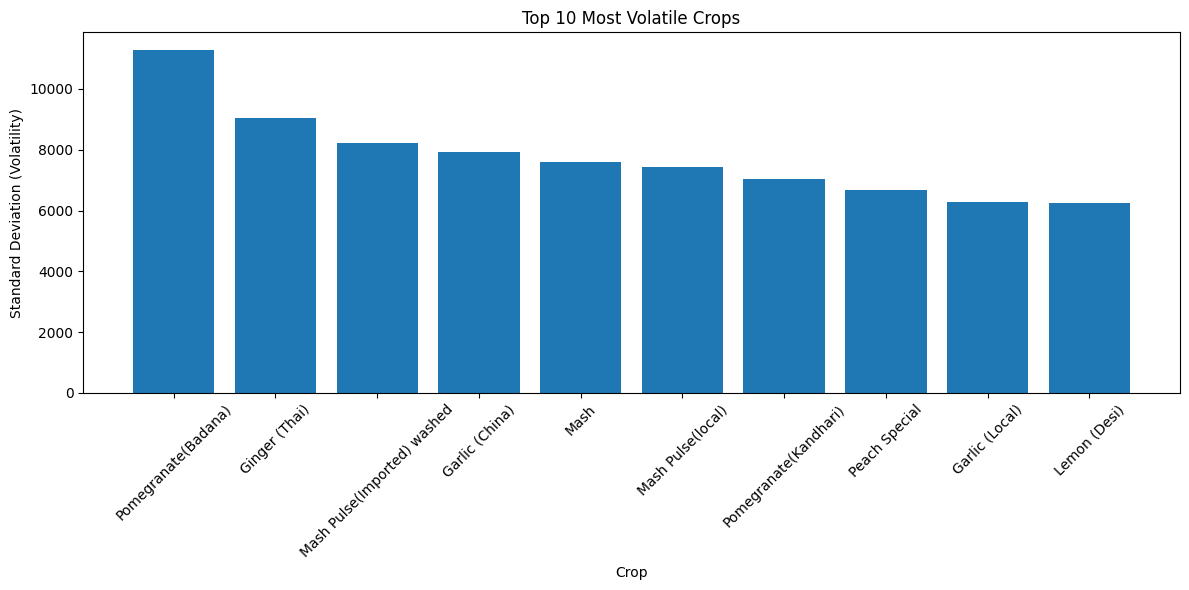

[SAVED] outputs/volatility/volatility.png


In [66]:

volatility_plot(df)

In [67]:
# 9. correlation Heatmap
def plot_correlation_heatmap(df, cmap='viridis'):
    """
    Generate and save correlation heatmap
    """

    create_dir("outputs/heatmap")

    # Select only numeric columns
    numerical_df = df.select_dtypes(include=[np.number])

    corr = numerical_df.corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap)

    plt.title("Correlation Heatmap")

    save_and_show("correlation_heatmap", "outputs/heatmap")

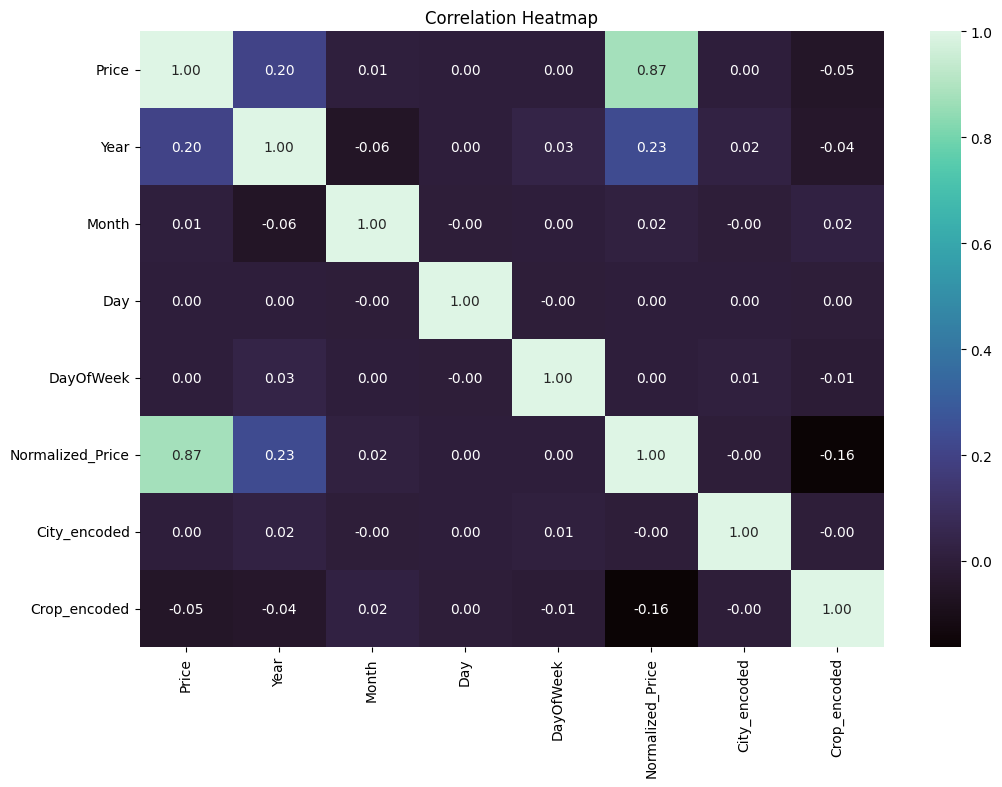

[SAVED] outputs/heatmap/correlation_heatmap.png


In [68]:
plot_correlation_heatmap(df, cmap='mako')

# 03_basic_time_series_analysis.py

In [69]:
# To Perform basic time-series analysis on a single representative series.
# It includes:
# - Time-series visualization
# - Moving averages
# - Rolling statistics
# - Basic trend understanding

In [70]:
# SELECT REPRESENTATIVE SERIES

def select_series(df):
    """
    Select most frequent (City, Crop) combination
    """

    print("[INFO] Selecting representative time-series...")

    group_sizes = df.groupby(["City", "Crop"]).size()
    city, crop = group_sizes.idxmax()

    subset = df[(df["City"] == city) & (df["Crop"] == crop)]
    subset = subset.sort_values("Date")

    print(f"Selected → City: {city}, Crop: {crop}")

    return subset, city, crop

In [71]:
select_series(df)

[INFO] Selecting representative time-series...
Selected → City: Vehari, Crop: Banana(DOZENS)


(           City       Date            Crop  Price  Year  Month  Day  \
 7326412  Vehari 2007-05-10  Banana(DOZENS)     30  2007      5   10   
 7326413  Vehari 2007-05-10  Banana(DOZENS)     30  2007      5   10   
 7326414  Vehari 2007-05-11  Banana(DOZENS)     34  2007      5   11   
 7326415  Vehari 2007-05-11  Banana(DOZENS)     34  2007      5   11   
 7326416  Vehari 2007-05-16  Banana(DOZENS)     39  2007      5   16   
 ...         ...        ...             ...    ...   ...    ...  ...   
 7335323  Vehari 2022-11-13  Banana(DOZENS)    101  2022     11   13   
 7335324  Vehari 2022-11-14  Banana(DOZENS)     99  2022     11   14   
 7335325  Vehari 2022-11-14  Banana(DOZENS)     99  2022     11   14   
 7335326  Vehari 2022-11-15  Banana(DOZENS)     99  2022     11   15   
 7335327  Vehari 2022-11-15  Banana(DOZENS)     99  2022     11   15   
 
          DayOfWeek  Normalized_Price  City_encoded  Crop_encoded  
 7326412          3          0.001715           132             6 

In [72]:
# PLOT ORIGINAL SERIES

def plot_series(df, city, crop):

    plt.figure()
    plt.plot(df["Date"], df["Price"])

    plt.title(f"Price Trend ({crop} - {city})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.tight_layout()
    save_and_show("plot_series", "outputs/basic_time_series")

[INFO] Selecting representative time-series...
Selected → City: Vehari, Crop: Banana(DOZENS)


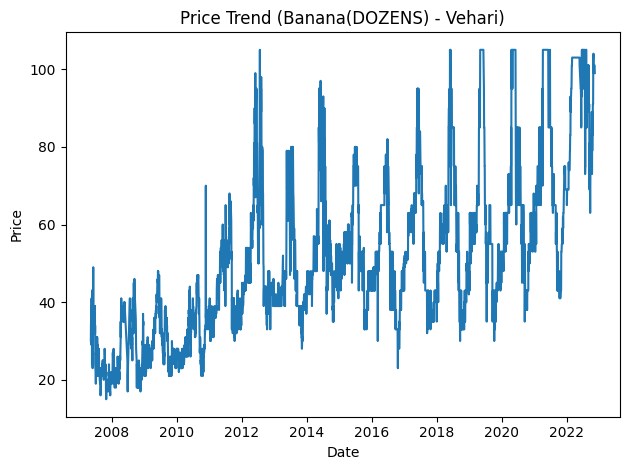

[SAVED] outputs/basic_time_series/plot_series.png


In [73]:
series, city, crop = select_series(df)
plot_series(series, city, crop)

In [74]:
# MOVING AVERAGE

def moving_average(df):

    print("[INFO] Calculating moving averages...")

    df["MA_7"] = df["Price"].rolling(window=7).mean()
    df["MA_30"] = df["Price"].rolling(window=30).mean()

    plt.figure()
    plt.plot(df["Date"], df["Price"], label="Original")
    plt.plot(df["Date"], df["MA_7"], label="7-Day MA")
    plt.plot(df["Date"], df["MA_30"], label="30-Day MA")

    plt.title("Moving Average Trends")
    plt.legend()
    save_and_show("moving_average", "outputs/basic_time_series")

    return df

[INFO] Calculating moving averages...


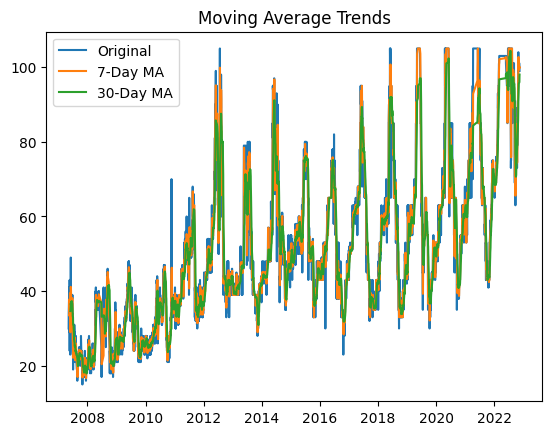

[SAVED] outputs/basic_time_series/moving_average.png


,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded,MA_7,MA_30
7326412,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN
7326413,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN
7326414,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN
7326415,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN
7326416,Vehari,2007-05-16,Banana(DOZENS),39,2007,5,16,2,0.002286,132,6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7335323,Vehari,2022-11-13,Banana(DOZENS),101,2022,11,13,6,0.006223,132,6,100.142857,96.400000
7335324,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,96.933333
7335325,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,97.466667
7335326,Vehari,2022-11-15,Banana(DOZENS),99,2022,11,15,1,0.006096,132,6,100.142857,97.733333


In [75]:
moving_average(series)

In [76]:
# ROLLING STATISTICS

def rolling_statistics(df):

    print("[INFO] Calculating rolling statistics...")

    df["Rolling_Mean"] = df["Price"].rolling(window=30).mean()
    df["Rolling_STD"] = df["Price"].rolling(window=30).std()

    plt.figure()
    plt.plot(df["Date"], df["Rolling_Mean"], label="Rolling Mean")
    plt.plot(df["Date"], df["Rolling_STD"], label="Rolling Std")

    plt.title("Rolling Statistics")
    plt.legend()
    save_and_show("rolling_statistics", "outputs/basic_time_series")

    return df

[INFO] Calculating rolling statistics...


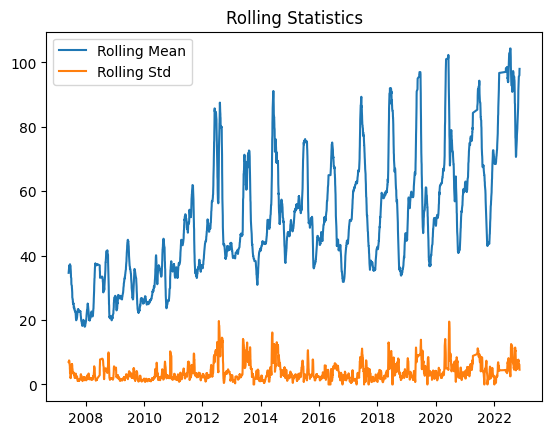

[SAVED] outputs/basic_time_series/rolling_statistics.png


,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded,MA_7,MA_30,Rolling_Mean,Rolling_STD
7326412,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN,NaN,NaN
7326413,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN,NaN,NaN
7326414,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN,NaN,NaN
7326415,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN,NaN,NaN
7326416,Vehari,2007-05-16,Banana(DOZENS),39,2007,5,16,2,0.002286,132,6,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7335323,Vehari,2022-11-13,Banana(DOZENS),101,2022,11,13,6,0.006223,132,6,100.142857,96.400000,96.400000,6.100311
7335324,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,96.933333,96.933333,5.564254
7335325,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,97.466667,97.466667,4.911165
7335326,Vehari,2022-11-15,Banana(DOZENS),99,2022,11,15,1,0.006096,132,6,100.142857,97.733333,97.733333,4.762883


In [77]:
rolling_statistics(series)

In [82]:
# MAIN PIPELINE

def basic_time_series_pipeline(df):

    print("\n======================================")
    print(" BASIC TIME-SERIES ANALYSIS ")
    print("======================================")

    series, city, crop = select_series(df)

    plot_series(series, city, crop)

    series = moving_average(series)

    rolling_statistics(series)

    print("\n[INFO] Basic time-series analysis completed.")

    return series


 BASIC TIME-SERIES ANALYSIS 
[INFO] Selecting representative time-series...
Selected → City: Vehari, Crop: Banana(DOZENS)


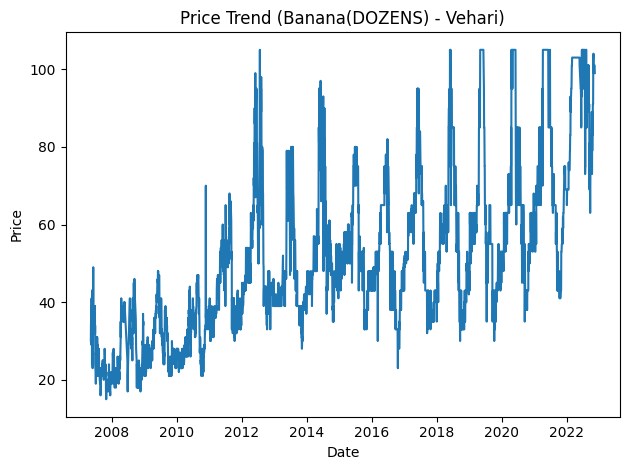

[SAVED] outputs/basic_time_series/plot_series.png
[INFO] Calculating moving averages...


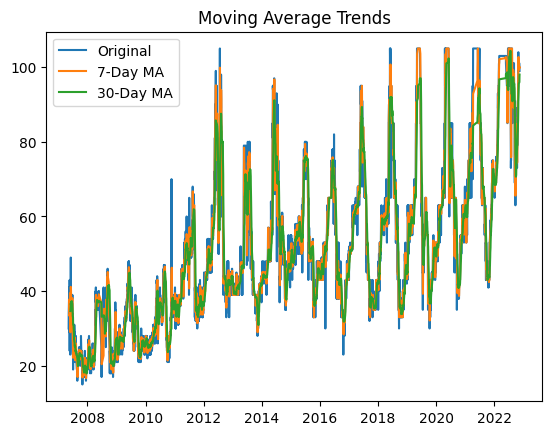

[SAVED] outputs/basic_time_series/moving_average.png
[INFO] Calculating rolling statistics...


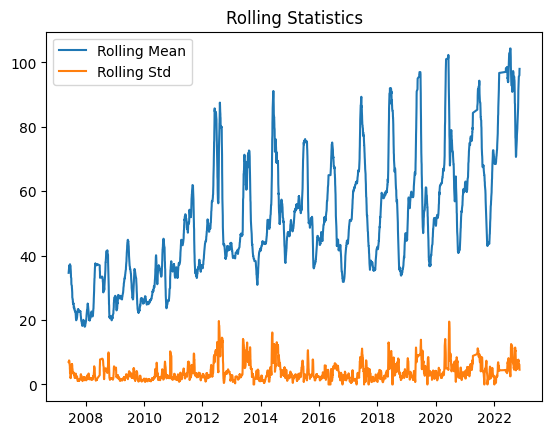

[SAVED] outputs/basic_time_series/rolling_statistics.png

[INFO] Basic time-series analysis completed.


,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded,MA_7,MA_30,Rolling_Mean,Rolling_STD
7326412,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN,NaN,NaN
7326413,Vehari,2007-05-10,Banana(DOZENS),30,2007,5,10,3,0.001715,132,6,NaN,NaN,NaN,NaN
7326414,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN,NaN,NaN
7326415,Vehari,2007-05-11,Banana(DOZENS),34,2007,5,11,4,0.001969,132,6,NaN,NaN,NaN,NaN
7326416,Vehari,2007-05-16,Banana(DOZENS),39,2007,5,16,2,0.002286,132,6,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7335323,Vehari,2022-11-13,Banana(DOZENS),101,2022,11,13,6,0.006223,132,6,100.142857,96.400000,96.400000,6.100311
7335324,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,96.933333,96.933333,5.564254
7335325,Vehari,2022-11-14,Banana(DOZENS),99,2022,11,14,0,0.006096,132,6,100.142857,97.466667,97.466667,4.911165
7335326,Vehari,2022-11-15,Banana(DOZENS),99,2022,11,15,1,0.006096,132,6,100.142857,97.733333,97.733333,4.762883


In [83]:
basic_time_series_pipeline(df)

In [84]:
df.head()

,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded
0,Abdulhakim,2019-12-21,Apple (Ammre),8550,2019,12,21,5,0.400406,0,0
1,Abdulhakim,2019-12-22,Apple (Ammre),8550,2019,12,22,6,0.400406,0,0
2,Abdulhakim,2019-12-25,Apple (Ammre),8550,2019,12,25,2,0.400406,0,0
3,Abdulhakim,2019-12-26,Apple (Ammre),8550,2019,12,26,3,0.400406,0,0
4,Abdulhakim,2019-12-28,Apple (Ammre),8550,2019,12,28,5,0.400406,0,0


In [ ]:
# EXPLANATION BLOCK
# 1. REPRESENTATIVE SERIES
# We select one (City, Crop) pair with maximum observations to ensure sufficient data for analysis.

# 2. ORIGINAL TIME-SERIES Shows raw price fluctuations over time.
# 3. MOVING AVERAGE - 7-day MA → short-term trend, - 30-day MA → long-term trend
# 4. ROLLING STATISTICS - Rolling Mean → trend stability, - Rolling Std → volatility
# 5. This step helps understand:
# price behavior over time, noise vs trend, volatility patterns
# This builds the foundation for advanced analysis.

# 04_advanced_time_series_analysis.py

In [85]:
# Advanced multi-series time-series analysis.
# This script extends basic analysis by:
# - Handling multiple time-series (multi-crop)
# - Performing decomposition (trend, seasonality, residual)
# - Testing stationarity (ADF)
# - Applying differencing
# - Comparing trends across crops
# - Generating analytical insights

In [86]:
# SELECT TOP CROPS

def select_top_crops(df, top_n=5):
    print(f"[INFO] Selecting top {top_n} crops...")

    return df["Crop"].value_counts().head(top_n).index

In [87]:
select_top_crops(df, top_n=5)

[INFO] Selecting top 5 crops...


Index(['Banana(DOZENS)', 'Garlic (China)', 'Cauliflower', 'Green Chilli',
       'Cucumber (Kheera)'],
      dtype='object', name='Crop')

In [88]:
# AGGREGATE TIME SERIES

def aggregate_series(df, crop):
    """
    Convert multi-city data → single time-series per crop
    """

    subset = df[df["Crop"] == crop]

    ts = subset.groupby("Date")["Price"].mean().sort_index()

    return ts

In [89]:
aggregate_series(df, 'Apple (Ammre)')

,Price
Date,
2007-05-08,3650.000000
2007-05-09,3872.000000
2007-05-10,3850.625000
2007-05-11,3731.875000
2007-05-12,3865.625000
...,...
2022-12-27,12996.153846
2022-12-28,13028.571429
2022-12-29,13154.000000


In [90]:
# MOVING AVERAGE (ADVANCED)

def moving_average(ts, crop):

    ma_30 = ts.rolling(window=30).mean()

    plt.figure()
    plt.plot(ts.index, ts.values, label="Original")
    plt.plot(ma_30.index, ma_30.values, label="30-Day MA")

    plt.title(f"Trend (Moving Average) - {crop}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    save_and_show("moving_average_advanced", "outputs/advanced_time_series")

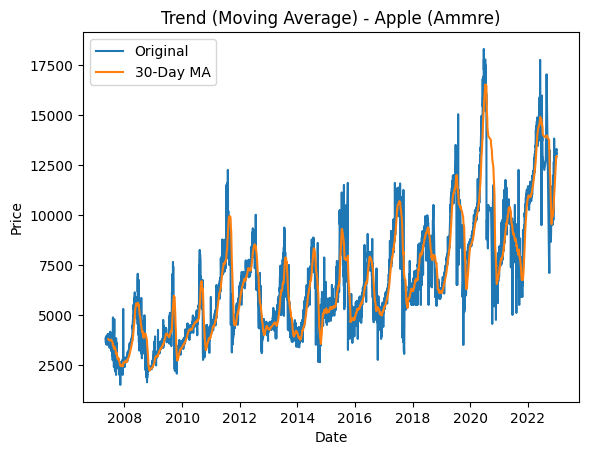

[SAVED] outputs/advanced_time_series/moving_average_advanced.png


In [91]:
moving_average(aggregate_series(df, 'Apple (Ammre)'), 'Apple (Ammre)')

In [92]:
# DECOMPOSITION

def decompose(ts, crop):

    print(f"[INFO] Decomposing {crop}...")

    result = seasonal_decompose(ts, model='additive', period=30)

    fig = result.plot() # Get the figure object
    plt.suptitle(f"Decomposition - {crop}") # Set the suptitle
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    save_and_show("decompose", "outputs/advanced_time_series")

    return result

[INFO] Decomposing Apple (Ammre)...


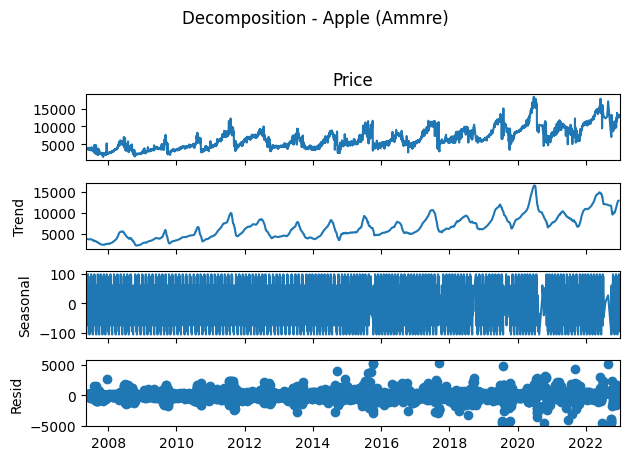

[SAVED] outputs/advanced_time_series/decompose.png


In [93]:
decompose(aggregate_series(df, 'Apple (Ammre)'), 'Apple (Ammre)')

In [94]:
# STATIONARITY TEST

def adf_test(ts, label):

    print(f"\n[INFO] ADF Test → {label}")

    result = adfuller(ts.dropna())

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("→ Stationary")
    else:
        print("→ Non-Stationary")

In [95]:
adf_test(aggregate_series(df, 'Apple (Ammre)'), 'Apple (Ammre)')


[INFO] ADF Test → Apple (Ammre)
ADF Statistic: -3.596854979972589
p-value: 0.005821439221132377
→ Stationary


In [96]:
# DIFFERENCING

def differencing(ts, crop):

    print(f"[INFO] Applying differencing → {crop}")

    diff = ts.diff()

    plt.figure()
    plt.plot(diff.index, diff.values)
    plt.title(f"Differenced Series - {crop}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    save_and_show("differencing", "outputs/advanced_time_series")

    return diff

[INFO] Applying differencing → Apple (Ammre)


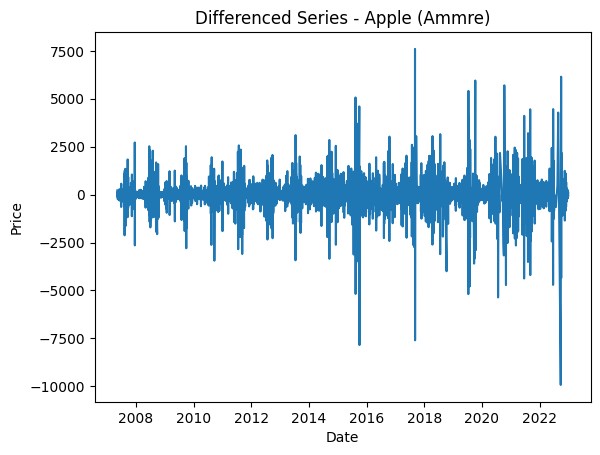

[SAVED] outputs/advanced_time_series/differencing.png


,Price
Date,
2007-05-08,NaN
2007-05-09,222.000000
2007-05-10,-21.375000
2007-05-11,-118.750000
2007-05-12,133.750000
...,...
2022-12-27,-160.989011
2022-12-28,32.417582
2022-12-29,125.428571


In [97]:
differencing(aggregate_series(df, 'Apple (Ammre)'), 'Apple (Ammre)')

In [98]:
# SEASONALITY (AGGREGATED)

def seasonal_pattern(ts, crop):

    monthly = ts.groupby(ts.index.month).mean()

    plt.figure()
    plt.plot(monthly.index, monthly.values)

    plt.title(f"Seasonality Pattern - {crop}")
    plt.xlabel("Month")
    plt.ylabel("Avg Price")
    save_and_show("seasonal_pattern", "outputs/advanced_time_series")
    plt.close()

    return monthly

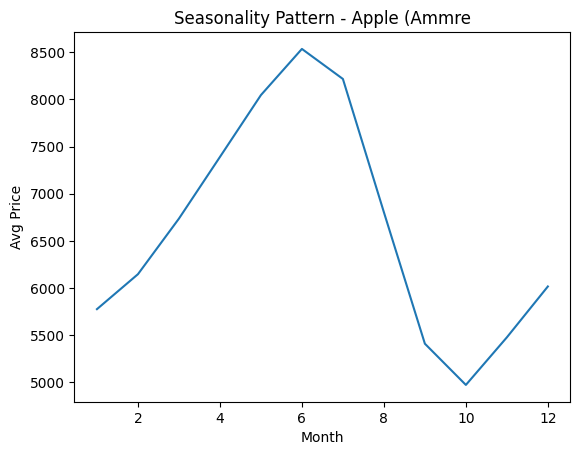

[SAVED] outputs/advanced_time_series/seasonal_pattern.png


,Price
Date,
1,5776.969475
2,6147.402729
3,6736.587079
4,7389.895634
5,8045.691347
6,8534.992290
7,8216.681204
8,6804.290748
9,5410.808741


In [99]:
seasonal_pattern(aggregate_series(df, 'Apple (Ammre)'), 'Apple (Ammre')

In [100]:
# COMPARATIVE ANALYSIS

def compare_trends(df, crops):

    plt.figure()

    for crop in crops:
        ts = aggregate_series(df, crop)
        plt.plot(ts.index, ts.values, label=crop)

    plt.title("Cross-Crop Trend Comparison")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    save_and_show("compare_trends", "outputs/advanced_time_series")

    return None

[INFO] Selecting top 5 crops...


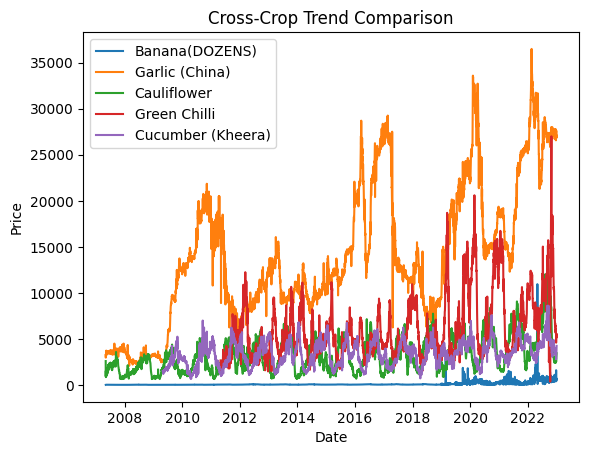

[SAVED] outputs/advanced_time_series/compare_trends.png


In [101]:
compare_trends(df, select_top_crops(df, top_n=5))

In [102]:
# Redefine save_and_show locally to ensure plt.close() is called
def save_and_show(name, folder):
    create_dir(folder)
    path = os.path.join(folder, f"{name}.png")
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {path}")
    plt.close() # Close the plot to free memory and prevent display issues

In [103]:
# Redefine moving_average with unique naming
def moving_average(ts, crop):
    print("[INFO] Calculating moving averages...")
    ma_30 = ts.rolling(window=30).mean()
    plt.figure()
    plt.plot(ts.index, ts.values, label="Original")
    plt.plot(ma_30.index, ma_30.values, label="30-Day MA")
    plt.title(f"Trend (Moving Average) - {crop}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    save_and_show(f"{crop.replace(' ', '_').replace('(', '').replace(')', '')}_moving_average_advanced", "outputs/advanced_time_series")
    return ts.to_frame(name='Price').assign(MA_30=ma_30) # Return updated series for potential chaining

In [104]:
# Redefine decompose with unique naming
def decompose(ts, crop):
    print(f"[INFO] Decomposing {crop}...")
    result = seasonal_decompose(ts, model='additive', period=30)
    fig = result.plot() # Get the figure object
    plt.suptitle(f"Decomposition - {crop}") # Set the suptitle
    fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    save_and_show(f"{crop.replace(' ', '_').replace('(', '').replace(')', '')}_decompose", "outputs/advanced_time_series")
    return result

In [105]:
# Redefine differencing with unique naming
def differencing(ts, crop):
    print(f"[INFO] Applying differencing → {crop}")
    diff = ts.diff()
    plt.figure()
    plt.plot(diff.index, diff.values)
    plt.title(f"Differenced Series - {crop}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    save_and_show(f"{crop.replace(' ', '_').replace('(', '').replace(')', '')}_differencing", "outputs/advanced_time_series")
    return diff

In [106]:
# Redefine seasonal_pattern with unique naming
def seasonal_pattern(ts, crop):
    monthly = ts.groupby(ts.index.month).mean()
    plt.figure()
    plt.plot(monthly.index, monthly.values)
    plt.title(f"Seasonality Pattern - {crop}")
    plt.xlabel("Month")
    plt.ylabel("Avg Price")
    save_and_show(f"{crop.replace(' ', '_').replace('(', '').replace(')', '')}_seasonal_pattern", "outputs/advanced_time_series")
    return monthly

In [107]:
# Redefine compare_trends to use the local save_and_show (and for clarity)
def compare_trends(df, crops):
    plt.figure()
    for crop in crops:
        ts = aggregate_series(df, crop)
        plt.plot(ts.index, ts.values, label=crop)
    plt.title("Cross-Crop Trend Comparison")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    save_and_show("compare_trends_top_crops", "outputs/advanced_time_series")
    return None

In [108]:
# Main Pipeline

def advanced_time_series_pipeline(file_path):
    print("\n======================================")
    print(" ADVANCED TIME-SERIES ANALYSIS ")
    print("======================================")

    # Select important crops
    crops = select_top_crops(df, top_n=5)

    # Compare overall trends
    compare_trends(df, crops)

    # Analyze each crop deeply
    for crop in crops:

        print("\n===================================")
        print(f" ANALYSIS FOR: {crop}")
        print("===================================")

        ts = aggregate_series(df, crop)

        # Trend smoothing
        moving_average(ts, crop)

        # Seasonality
        seasonal_pattern(ts, crop)

        # Decomposition
        decompose(ts, crop)

        # Stationarity
        adf_test(ts, f"{crop} (Original)")

        # Differencing
        diff = differencing(ts, crop)

        # Re-test stationarity
        adf_test(diff, f"{crop} (Differenced)")

    print("\n[INFO] Advanced time-series analysis completed.")


 ADVANCED TIME-SERIES ANALYSIS 
[INFO] Selecting top 5 crops...


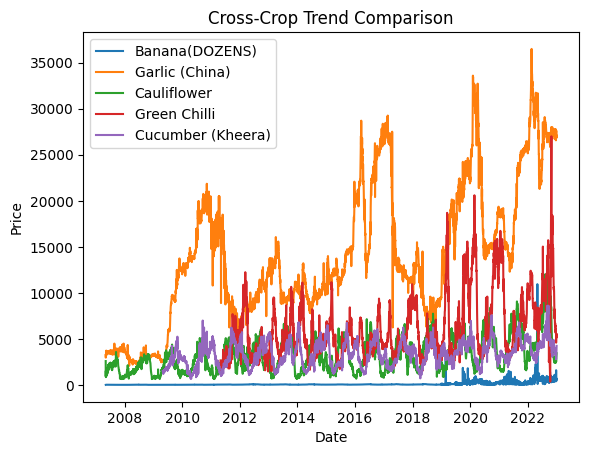

[SAVED] outputs/advanced_time_series/compare_trends_top_crops.png

 ANALYSIS FOR: Banana(DOZENS)
[INFO] Calculating moving averages...


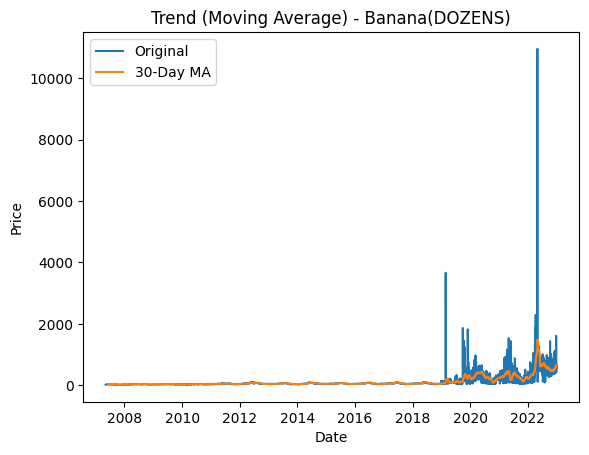

[SAVED] outputs/advanced_time_series/BananaDOZENS_moving_average_advanced.png


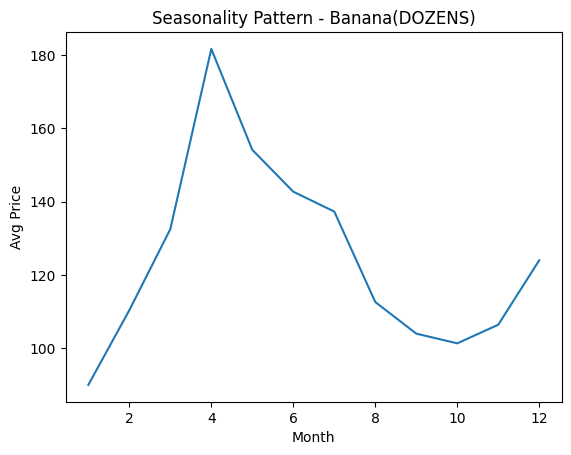

[SAVED] outputs/advanced_time_series/BananaDOZENS_seasonal_pattern.png
[INFO] Decomposing Banana(DOZENS)...


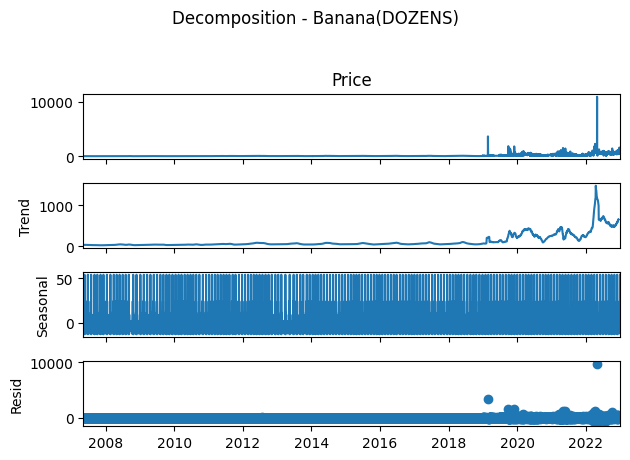

[SAVED] outputs/advanced_time_series/BananaDOZENS_decompose.png

[INFO] ADF Test → Banana(DOZENS) (Original)
ADF Statistic: -2.7960924829667824
p-value: 0.05883410053918348
→ Non-Stationary
[INFO] Applying differencing → Banana(DOZENS)


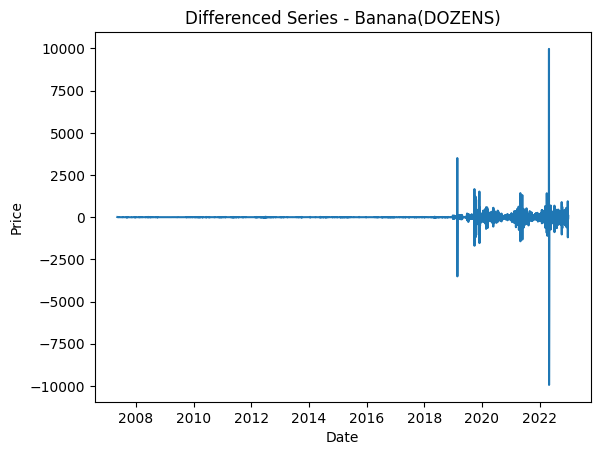

[SAVED] outputs/advanced_time_series/BananaDOZENS_differencing.png

[INFO] ADF Test → Banana(DOZENS) (Differenced)
ADF Statistic: -19.75790192452283
p-value: 0.0
→ Stationary

 ANALYSIS FOR: Garlic (China)
[INFO] Calculating moving averages...


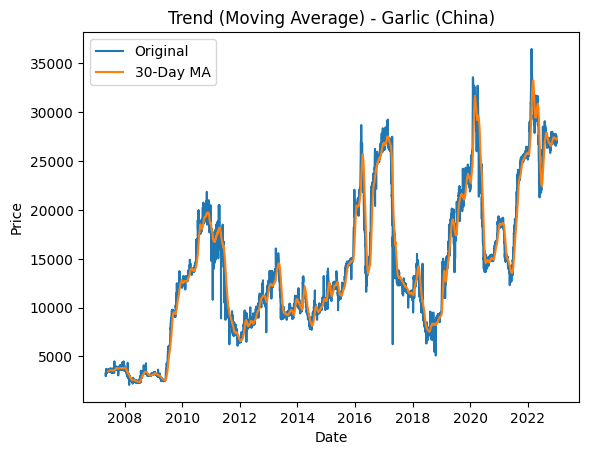

[SAVED] outputs/advanced_time_series/Garlic_China_moving_average_advanced.png


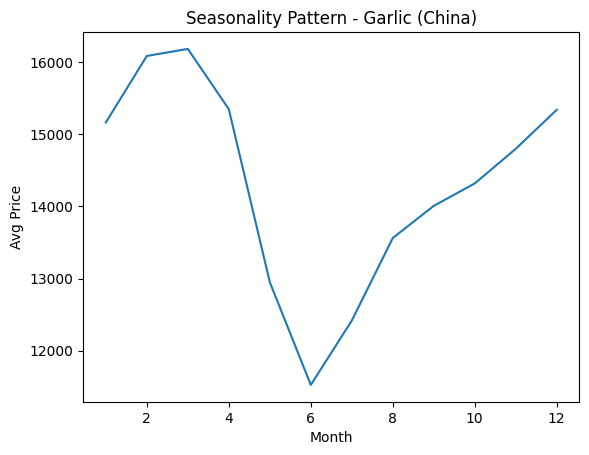

[SAVED] outputs/advanced_time_series/Garlic_China_seasonal_pattern.png
[INFO] Decomposing Garlic (China)...


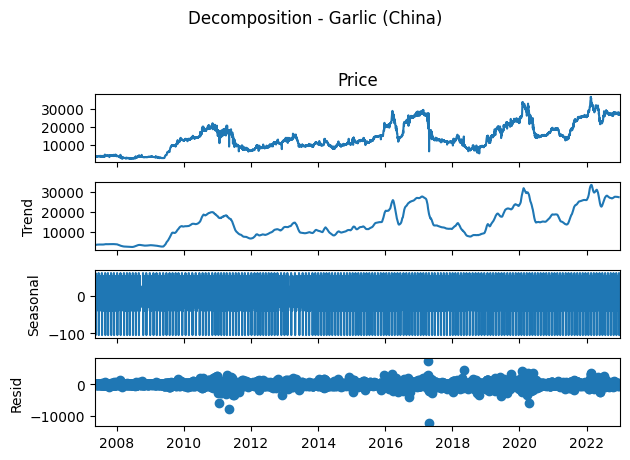

[SAVED] outputs/advanced_time_series/Garlic_China_decompose.png

[INFO] ADF Test → Garlic (China) (Original)
ADF Statistic: -2.1375615839906894
p-value: 0.2296814882759599
→ Non-Stationary
[INFO] Applying differencing → Garlic (China)


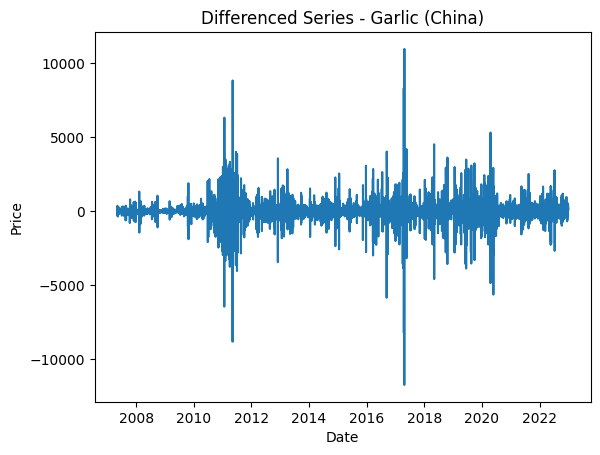

[SAVED] outputs/advanced_time_series/Garlic_China_differencing.png

[INFO] ADF Test → Garlic (China) (Differenced)
ADF Statistic: -13.378792807700567
p-value: 5.0259158213266475e-25
→ Stationary

 ANALYSIS FOR: Cauliflower
[INFO] Calculating moving averages...


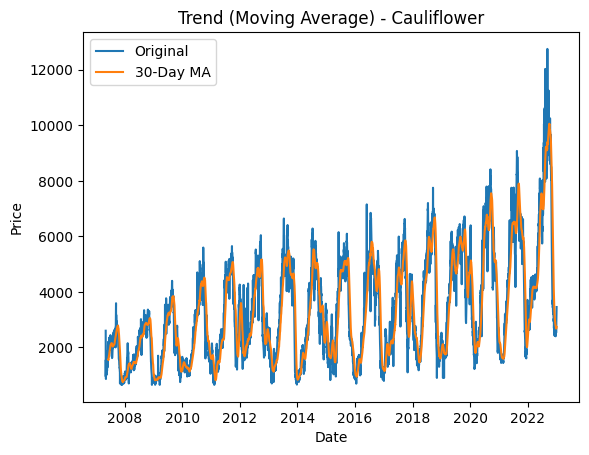

[SAVED] outputs/advanced_time_series/Cauliflower_moving_average_advanced.png


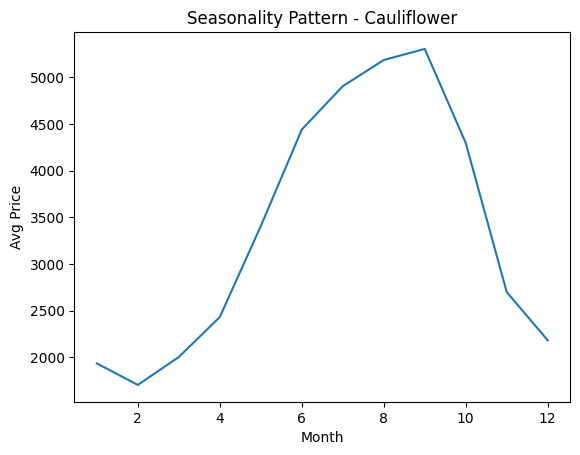

[SAVED] outputs/advanced_time_series/Cauliflower_seasonal_pattern.png
[INFO] Decomposing Cauliflower...


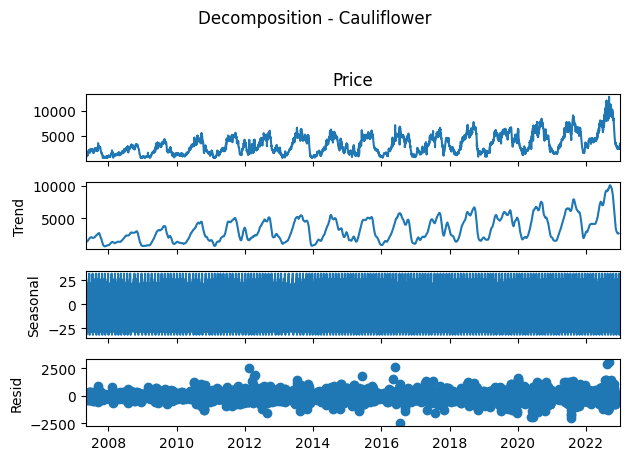

[SAVED] outputs/advanced_time_series/Cauliflower_decompose.png

[INFO] ADF Test → Cauliflower (Original)
ADF Statistic: -5.023932364172659
p-value: 1.9895856350240677e-05
→ Stationary
[INFO] Applying differencing → Cauliflower


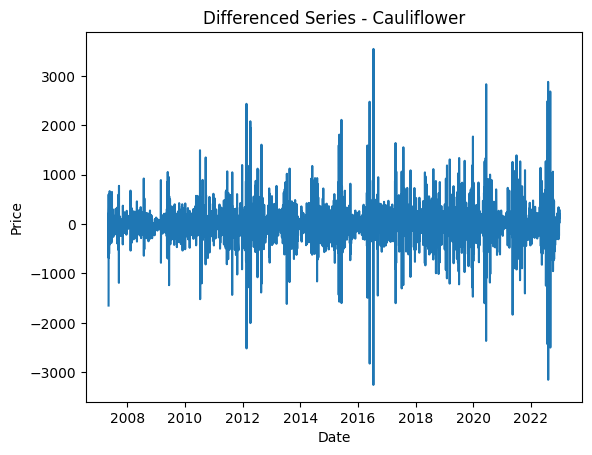

[SAVED] outputs/advanced_time_series/Cauliflower_differencing.png

[INFO] ADF Test → Cauliflower (Differenced)
ADF Statistic: -12.53159225303465
p-value: 2.4218662131468442e-23
→ Stationary

 ANALYSIS FOR: Green Chilli
[INFO] Calculating moving averages...


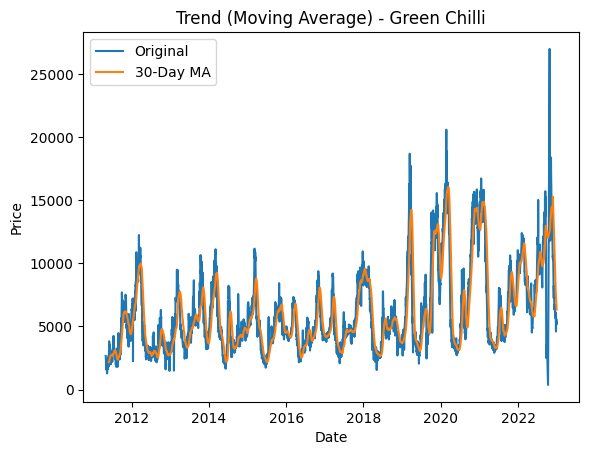

[SAVED] outputs/advanced_time_series/Green_Chilli_moving_average_advanced.png


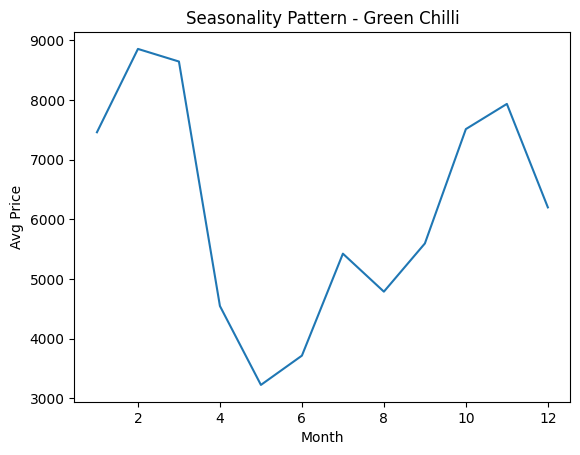

[SAVED] outputs/advanced_time_series/Green_Chilli_seasonal_pattern.png
[INFO] Decomposing Green Chilli...


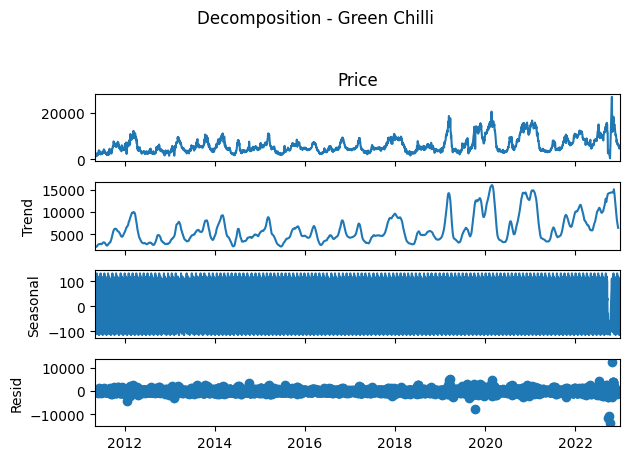

[SAVED] outputs/advanced_time_series/Green_Chilli_decompose.png

[INFO] ADF Test → Green Chilli (Original)
ADF Statistic: -6.03359040085882
p-value: 1.3990826720695762e-07
→ Stationary
[INFO] Applying differencing → Green Chilli


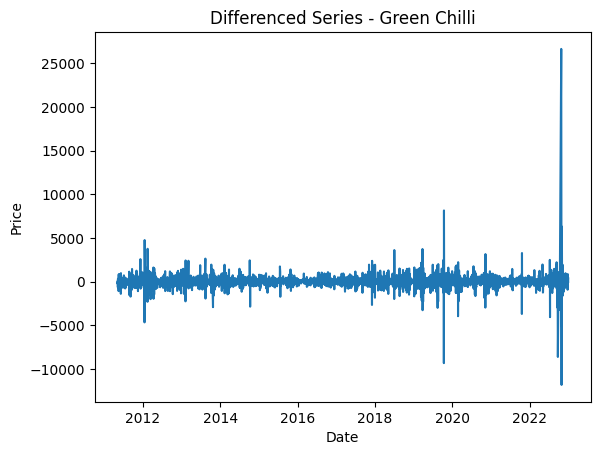

[SAVED] outputs/advanced_time_series/Green_Chilli_differencing.png

[INFO] ADF Test → Green Chilli (Differenced)
ADF Statistic: -12.868046943378893
p-value: 4.946706143528376e-24
→ Stationary

 ANALYSIS FOR: Cucumber (Kheera)
[INFO] Calculating moving averages...


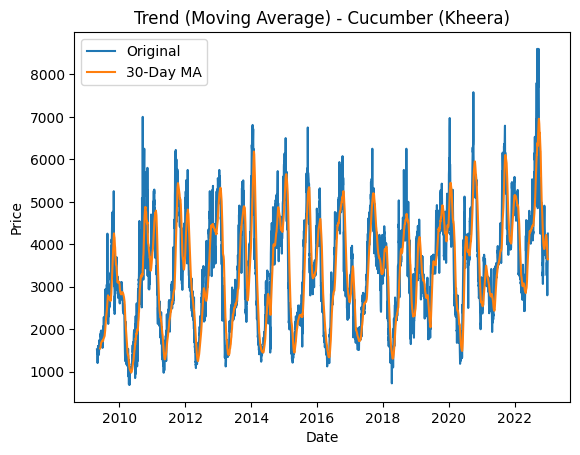

[SAVED] outputs/advanced_time_series/Cucumber_Kheera_moving_average_advanced.png


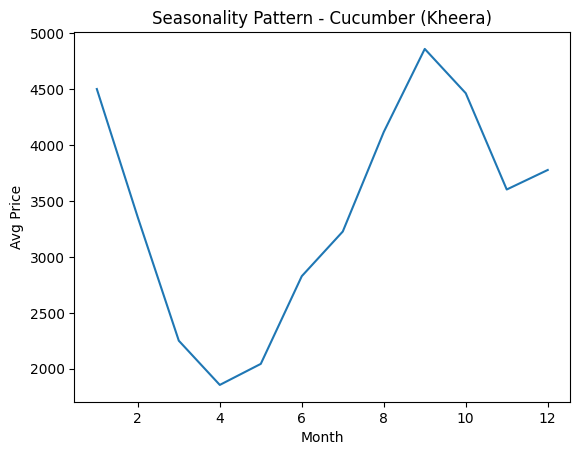

[SAVED] outputs/advanced_time_series/Cucumber_Kheera_seasonal_pattern.png
[INFO] Decomposing Cucumber (Kheera)...


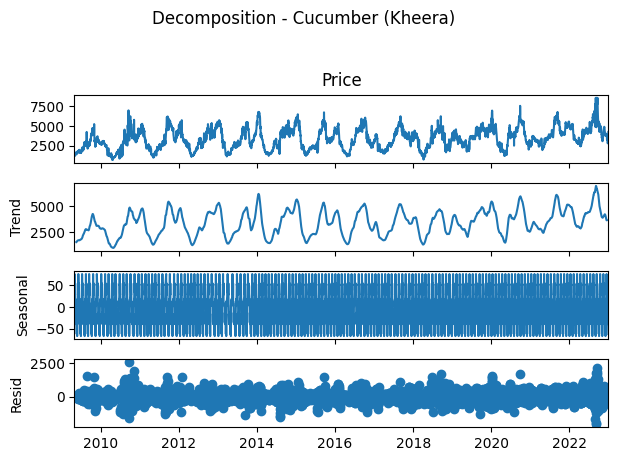

[SAVED] outputs/advanced_time_series/Cucumber_Kheera_decompose.png

[INFO] ADF Test → Cucumber (Kheera) (Original)
ADF Statistic: -6.085555415580635
p-value: 1.0665443310045413e-07
→ Stationary
[INFO] Applying differencing → Cucumber (Kheera)


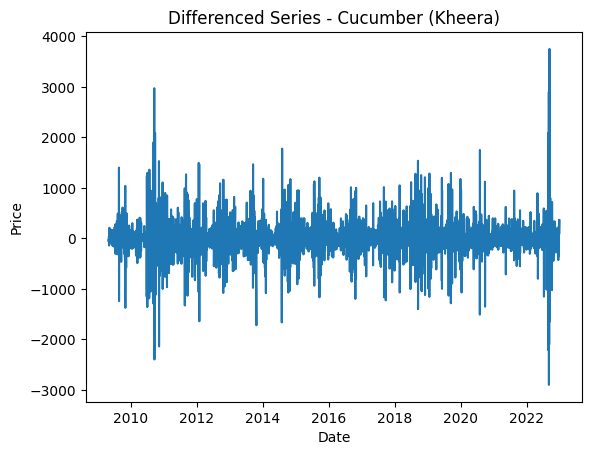

[SAVED] outputs/advanced_time_series/Cucumber_Kheera_differencing.png

[INFO] ADF Test → Cucumber (Kheera) (Differenced)
ADF Statistic: -16.93215739661357
p-value: 9.758593601393135e-30
→ Stationary

[INFO] Advanced time-series analysis completed.


In [109]:
# Call the redefined pipeline
advanced_time_series_pipeline(df)

In [110]:
df.head()

,City,Date,Crop,Price,Year,Month,Day,DayOfWeek,Normalized_Price,City_encoded,Crop_encoded
0,Abdulhakim,2019-12-21,Apple (Ammre),8550,2019,12,21,5,0.400406,0,0
1,Abdulhakim,2019-12-22,Apple (Ammre),8550,2019,12,22,6,0.400406,0,0
2,Abdulhakim,2019-12-25,Apple (Ammre),8550,2019,12,25,2,0.400406,0,0
3,Abdulhakim,2019-12-26,Apple (Ammre),8550,2019,12,26,3,0.400406,0,0
4,Abdulhakim,2019-12-28,Apple (Ammre),8550,2019,12,28,5,0.400406,0,0


In [111]:
# 1. MULTI-SERIES HANDLING
# Unlike basic analysis (single series), this script analyzes multiple crops, making it scalable and realistic.

# 2. AGGREGATION STRATEGY
# We convert multi-city data into a single representative series per crop, reducing complexity while preserving trends.

# 3. DECOMPOSITION
# We explicitly separate: 1. Trend 2. Seasonality 3.Noise
# This reveals hidden patterns not visible in raw data.

# 4. STATIONARITY TESTING:  We validate statistical assumptions using ADF test.

# 5. DIFFERENCING
# We transform non-stationary data into stationary form, which is critical for time-series modeling.

# 6. COMPARATIVE ANALYSIS
# We compare multiple crops to identify:
# - stable vs volatile crops, seasonal vs non-seasonal behavior

# 7. REAL-WORLD CHALLENGE HANDLING
# This script handles:
# - large dataset (via top-N selection), multiple time-series, noisy data, irregular patterns

# CONCLUSION:
# This script transforms raw agricultural price data into structured insights, fulfilling the goal of Time-Series Data Analysis and Trend Discovery.

# 05_Temporal _feature_engineering.py

In [112]:
# 1. ADVANCED TIME-SERIES FEATURES

def create_advanced_ts_features(df):
    print("[INFO] Creating advanced time-series features...")

    df = df.sort_values(["City", "Crop", "Date"]) # Ensure correct sorting (CRITICAL)

    # LAG FEATURES (Temporal Dependency)
    df["lag_1"] = df.groupby(["City", "Crop"])["Price"].shift(1)
    df["lag_3"] = df.groupby(["City", "Crop"])["Price"].shift(3)
    df["lag_7"] = df.groupby(["City", "Crop"])["Price"].shift(7)
    df["lag_14"] = df.groupby(["City", "Crop"])["Price"].shift(14)

    # ROLLING WINDOW FEATURES (Trend + Stability)
    df["rolling_mean_3"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=3).mean()
    )
    df["rolling_mean_7"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=7).mean()
    )
    df["rolling_mean_14"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=14).mean()
    )

    df["rolling_std_3"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=3).std()
    )
    df["rolling_std_7"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=7).std()
    )

    # MOMENTUM / TREND FEATURES
    df["price_diff"] = df.groupby(["City", "Crop"])["Price"].diff()
    df["price_pct_change"] = df.groupby(["City", "Crop"])["Price"].pct_change()

    # EXPONENTIAL MOVING AVERAGE (ADVANCED TREND)
    df["ema_7"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.ewm(span=7, adjust=False).mean()
    )

    df["ema_14"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.ewm(span=14, adjust=False).mean()
    )

    # VOLATILITY FEATURES
    df["volatility_7"] = df.groupby(["City", "Crop"])["Price"].transform(
        lambda x: x.rolling(window=7).std()
    )

    # SEASONAL INTERACTION (IMPORTANT FOR CROPS)
    df["month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

    return df

In [113]:
# 2. HANDLE MISSING VALUES

def clean_after_feature_engineering(df):
    print("[INFO] Cleaning NaNs and Infs after feature creation...")
    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clean = df.dropna()

    print("Remaining rows:", df_clean.shape)
    return df_clean

In [114]:
# 3. FEATURE MATRIX (FOR DATA MINING)

def build_feature_matrix(df):
    print("[INFO] Building feature matrix...")

    feature_cols = [
        "Normalized_Price",  # Core signal

        "lag_1", "lag_3", "lag_7", "lag_14",  # Lag features

        "rolling_mean_3", "rolling_mean_7", "rolling_mean_14",  # Rolling stats
        "rolling_std_3", "rolling_std_7",

        "price_diff", "price_pct_change",  # Trend & momentum

        "ema_7", "ema_14",   # EMA

        "volatility_7",  # Volatility

        "month_sin", "month_cos",  # Seasonal encoding

        "City_encoded", "Crop_encoded"  # Categorical encodings (already created earlier)
    ]

    X = df[feature_cols]

    print("Feature matrix shape:", X.shape)
    return X

In [115]:
# 4. FEATURE SCALING (MANDATORY)

def scale_features(X):
    print("[INFO] Scaling features...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled

In [116]:
# 5. PIPELINE WRAPPER

def run_advanced_feature_engineering(df):
    print("\n===== ADVANCED FEATURE ENGINEERING STARTED =====")

    df = create_advanced_ts_features(df)
    df = clean_after_feature_engineering(df)

    X = build_feature_matrix(df)
    X_scaled = scale_features(X)

    print("===== FEATURE ENGINEERING COMPLETED =====\n")

    return df, X, X_scaled

In [117]:
run_advanced_feature_engineering(df)


===== ADVANCED FEATURE ENGINEERING STARTED =====
[INFO] Creating advanced time-series features...
[INFO] Cleaning NaNs and Infs after feature creation...
Remaining rows: (5566840, 27)
[INFO] Building feature matrix...
Feature matrix shape: (5566840, 19)
[INFO] Scaling features...
===== FEATURE ENGINEERING COMPLETED =====



(               City       Date                          Crop  Price  Year  \
 26       Abdulhakim 2010-09-08                Apple (Gatcha)   9300  2010   
 27       Abdulhakim 2010-09-17                Apple (Gatcha)   9300  2010   
 28       Abdulhakim 2010-09-20                Apple (Gatcha)   4300  2010   
 29       Abdulhakim 2010-09-22                Apple (Gatcha)   8300  2010   
 30       Abdulhakim 2010-09-29                Apple (Gatcha)   8800  2010   
 ...             ...        ...                           ...    ...   ...   
 7651133    kotmoman 2022-01-18  feutral early(100 Pcs) فروٹر    815  2022   
 7651134    kotmoman 2022-01-19  feutral early(100 Pcs) فروٹر    815  2022   
 7651135    kotmoman 2022-01-20  feutral early(100 Pcs) فروٹر    815  2022   
 7651136    kotmoman 2022-01-25  feutral early(100 Pcs) فروٹر    815  2022   
 7651137    kotmoman 2022-01-26  feutral early(100 Pcs) فروٹر    815  2022   
 
          Month  Day  DayOfWeek  Normalized_Price  City_encode

In [ ]:
# Advanced feature engineering was performed to transform raw temporal observations into a high-dimensional
# representation capturing temporal dependencies, seasonal cycles, volatility, and trend dynamics.
# Lag features model temporal memory, rolling statistics capture local trends, while exponential
# moving averages provide smoothed trend estimation. Additionally, cyclical encoding of time variables
# ensures proper representation of seasonal effects inherent in agricultural data.